In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, cohen_kappa_score

d:\Documents\jean\sem 5\deep learning\deep_learn_new\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
file_path = 'Mohler_dataset_hf/Mohler_dataset_hf/data/raw-oe-00001.parquet'
df = pd.read_parquet(file_path)
df.head(20)

,id,question,instructor_answer,student_answer,score_grader_1,score_grader_2,score_avg
0,E01.Q01.A00,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,High risk problems are address in the prototyp...,3.0,4.0,3.5
1,E01.Q01.A01,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,To simulate portions of the desired final prod...,5.0,5.0,5.0
2,E01.Q01.A02,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,A prototype program simulates the behaviors of...,3.0,5.0,4.0
3,E01.Q01.A03,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,Defined in the Specification phase a prototype...,5.0,5.0,5.0
4,E01.Q01.A04,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,It is used to let the users have a first idea ...,3.0,3.0,3.0
5,E01.Q01.A05,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,To find problem and errors in a program before...,2.0,2.0,2.0
6,E01.Q01.A06,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,To address major issues in the creation of the...,2.0,3.0,2.5
7,E01.Q01.A07,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,you can break the whole program into prototype...,5.0,5.0,5.0
8,E01.Q01.A08,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,-To provide an example or model of how the fin...,2.0,5.0,3.5
9,E01.Q01.A09,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,Simulating the behavior of only a portion of t...,5.0,5.0,5.0


In [3]:
df['score_avg'] = (df['score_grader_1'] + df['score_grader_2']) / 2
df.head(20)

,id,question,instructor_answer,student_answer,score_grader_1,score_grader_2,score_avg
0,E01.Q01.A00,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,High risk problems are address in the prototyp...,3.0,4.0,3.5
1,E01.Q01.A01,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,To simulate portions of the desired final prod...,5.0,5.0,5.0
2,E01.Q01.A02,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,A prototype program simulates the behaviors of...,3.0,5.0,4.0
3,E01.Q01.A03,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,Defined in the Specification phase a prototype...,5.0,5.0,5.0
4,E01.Q01.A04,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,It is used to let the users have a first idea ...,3.0,3.0,3.0
5,E01.Q01.A05,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,To find problem and errors in a program before...,2.0,2.0,2.0
6,E01.Q01.A06,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,To address major issues in the creation of the...,2.0,3.0,2.5
7,E01.Q01.A07,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,you can break the whole program into prototype...,5.0,5.0,5.0
8,E01.Q01.A08,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,-To provide an example or model of how the fin...,2.0,5.0,3.5
9,E01.Q01.A09,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,Simulating the behavior of only a portion of t...,5.0,5.0,5.0


In [4]:
print(len(df), 'data')

2273 data


In [5]:
def preprocessing(text):
    #empty handling
    if text is None:
        return ""
    
    text = text.strip()
    if len(text) == 0:
        return ""

    #lower casing
    text = text.lower()

    #normalize repeated char
    text = re.sub(r'(.)\1{2,}', r'\1\1', text) #max 2x ngulang char yg sama
    
    #remove noise
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'\S+@\S+', '', text)          # remove emails
    text = re.sub(r'\d+', '', text)              # remove numbers

    #remove symbols
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    #remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [6]:
df['instructor_answer'] = df['instructor_answer'].apply(preprocessing)
df['student_answer'] = df['student_answer'].apply(preprocessing)

df['instructor_answer'].head()

0    to simulate the behaviour of portions of the d...
1    to simulate the behaviour of portions of the d...
2    to simulate the behaviour of portions of the d...
3    to simulate the behaviour of portions of the d...
4    to simulate the behaviour of portions of the d...
Name: instructor_answer, dtype: object

In [7]:
df['student_answer'].head()

0    high risk problems are address in the prototyp...
1    to simulate portions of the desired final prod...
2    a prototype program simulates the behaviors of...
3    defined in the specification phase a prototype...
4    it is used to let the users have a first idea ...
Name: student_answer, dtype: object

In [8]:
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
test_df, val_df = train_test_split(temp_df, test_size=0.5, random_state=42)

#70 15 15
print(len(train_df))
print(len(val_df))
print(len(test_df))

1591
341
341


### No FineTune

In [9]:
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

In [10]:
model = SentenceTransformer("all-MiniLM-L6-v2") #pretrained, frozen

train_student_emb = model.encode(train_df['student_answer'].tolist(), show_progress_bar=True)
train_instructor_emb = model.encode(train_df['instructor_answer'].tolist(),  show_progress_bar=True)

test_student_emb = model.encode(test_df['student_answer'])
test_instructor_emb = model.encode(test_df['instructor_answer'])

val_student_emb = model.encode(val_df['student_answer'])
val_instructor_emb = model.encode(val_df['instructor_answer'])

Batches: 100%|██████████| 50/50 [00:23<00:00,  2.11it/s]


In [11]:
train_sim = cosine_similarity(train_student_emb, train_instructor_emb).diagonal()
test_sim = cosine_similarity(test_student_emb, test_instructor_emb).diagonal()
val_sim = cosine_similarity(val_student_emb, val_instructor_emb).diagonal()

train_df['cosine sim'] = train_sim

In [12]:
x_train = train_sim.reshape(-1, 1)
y_train = train_df['score_avg'].values

x_val = val_sim.reshape(-1, 1)
y_val = val_df['score_avg'].values

x_test = test_sim.reshape(-1, 1)

In [13]:
linear = LinearRegression()
linear.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
#validation cek overfit
val_pred = linear.predict(x_val)

pearson_corr, _ = pearsonr(y_val, val_pred)
mae = mean_absolute_error(y_val, val_pred)
val_pred_round = np.rint(val_pred).astype(int)

qwk = cohen_kappa_score(
    y_val.astype(int),
    val_pred_round,
    weights="quadratic"
)

print("Pearson VAL:", pearson_corr)
print("MAE VAL:", mae)
print("QWK VAL:", qwk)

Pearson VAL: 0.24582162
MAE VAL: 1.5385481119155884
QWK VAL: 0.15615802270525214


In [15]:
val_df['Predicted Score'] = val_pred
val_df.head()

,id,question,instructor_answer,student_answer,score_grader_1,score_grader_2,score_avg,Predicted Score
0,E09.Q01.A24,What is a queue?,a data structure that can store elements which...,a queue is a list of things that follows the f...,5.0,5.0,5.0,4.570783
1,E03.Q01.A07,What does a function signature include?,the name of the function and the types of the ...,input parameters and return type,5.0,1.0,3.0,5.107529
2,E01.Q03.A09,What are the main advantages associated with o...,abstraction and reusability,reusability and ease of maintenance,5.0,3.0,4.0,5.562881
3,E03.Q04.A23,What is the main advantage associated with fun...,it avoids making copies of large data structur...,the data can be modified directly instead of m...,4.0,4.0,4.0,5.183708
4,E06.Q07.A02,What is a function pointer?,the address of the location in memory where th...,function pointers are pointers ie variables wh...,5.0,5.0,5.0,5.413073


In [16]:
test_pred = linear.predict(x_test)

pearson_corr, _ = pearsonr(y_val, val_pred)
mae = mean_absolute_error(y_val, val_pred)
val_pred_round = np.rint(val_pred).astype(int)

qwk = cohen_kappa_score(
    y_val.astype(int),
    val_pred_round,
    weights="quadratic"
)

print("Pearson VAL:", pearson_corr)
print("MAE VAL:", mae)
print("QWK VAL:", qwk)

Pearson VAL: 0.24582162
MAE VAL: 1.5385481119155884
QWK VAL: 0.15615802270525214


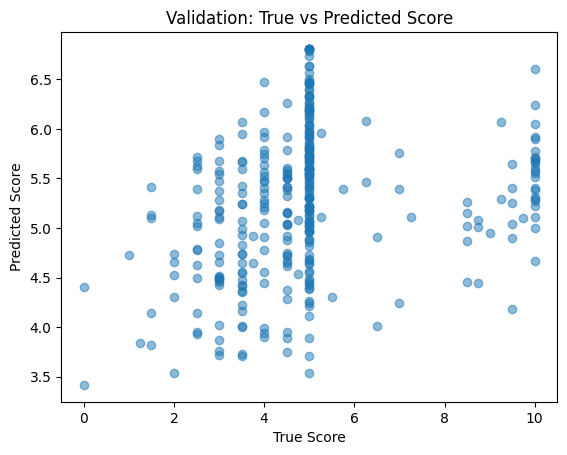

In [17]:
plt.scatter(y_val, val_pred, alpha=0.5)
plt.xlabel("True Score")
plt.ylabel("Predicted Score")
plt.title("Validation: True vs Predicted Score")
plt.show()

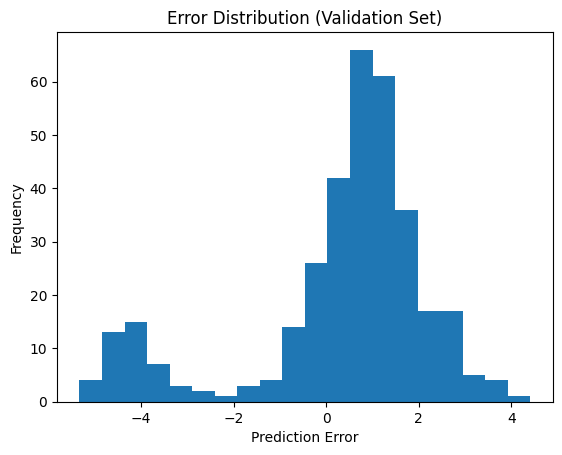

In [18]:
errors = val_pred - y_val

plt.figure()
plt.hist(errors, bins=20)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution (Validation Set)")
plt.show()

In [19]:
test_df['Predicted Score'] = test_pred
test_df.head()

,id,question,instructor_answer,student_answer,score_grader_1,score_grader_2,score_avg,Predicted Score
0,E06.Q07.A13,What is a function pointer?,the address of the location in memory where th...,they are pointers that contain the addresses t...,5.0,5.0,5.0,5.215740
1,E12.Q05.A00,What is the advantage of linked lists over arr...,linked lists are dynamic structures which allo...,a link list can grow to a infinite size as a a...,10.0,10.0,10.0,5.439632
2,E08.Q04.A18,How can you implement a stack with a list?,keep the top of the stack pointing to the head...,elements are only inserted and removed from th...,4.0,5.0,4.5,5.174628
3,E12.Q07.A19,What are the main operations associated with a...,push and pop,push and pop,10.0,10.0,10.0,6.806697
4,E11.Q03.A09,How are objects initialized when they are crea...,by using constructors,constructors default when not provided by user...,10.0,10.0,10.0,5.286062


## with feature engineering

In [20]:
# extract length feature
for df in [train_df, val_df, test_df]:
    df['len_student'] = df['student_answer'].str.split().str.len()
    df['len_instr']   = df['instructor_answer'].str.split().str.len()
    df['len_ratio']   = df['len_student'] / (df['len_instr'] + 1)

#embedding difference -> dimensi mana student beda dr jwbn ideal
#way better than just calculate cosine sim
train_diff = np.abs(train_student_emb - train_instructor_emb)
val_diff   = np.abs(val_student_emb - val_instructor_emb)
test_diff  = np.abs(test_student_emb - test_instructor_emb)

df.head()

,id,question,instructor_answer,student_answer,score_grader_1,score_grader_2,score_avg,Predicted Score,len_student,len_instr,len_ratio
0,E06.Q07.A13,What is a function pointer?,the address of the location in memory where th...,they are pointers that contain the addresses t...,5.0,5.0,5.0,5.215740,29,12,2.230769
1,E12.Q05.A00,What is the advantage of linked lists over arr...,linked lists are dynamic structures which allo...,a link list can grow to a infinite size as a a...,10.0,10.0,10.0,5.439632,16,16,0.941176
2,E08.Q04.A18,How can you implement a stack with a list?,keep the top of the stack pointing to the head...,elements are only inserted and removed from th...,4.0,5.0,4.5,5.174628,20,31,0.625000
3,E12.Q07.A19,What are the main operations associated with a...,push and pop,push and pop,10.0,10.0,10.0,6.806697,3,3,0.750000
4,E11.Q03.A09,How are objects initialized when they are crea...,by using constructors,constructors default when not provided by user...,10.0,10.0,10.0,5.286062,11,3,2.750000


In [21]:
x_train = np.hstack([
    train_sim.reshape(-1, 1),
    train_df[['len_student', 'len_ratio']].values,
    train_diff
])

x_val = np.hstack([
    val_sim.reshape(-1, 1),
    val_df[['len_student', 'len_ratio']].values,
    val_diff
])

x_test = np.hstack([
    test_sim.reshape(-1, 1),
    test_df[['len_student', 'len_ratio']].values,
    test_diff
])

#merge semua fitur jadi satu tabel angka

In [22]:
y_train = train_df['score_avg'].values
y_val   = val_df['score_avg'].values

linear.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
#validation cek overfit
val_pred = linear.predict(x_val)

pearson_corr, _ = pearsonr(y_val, val_pred)
mae = mean_absolute_error(y_val, val_pred)
val_pred_round = np.rint(val_pred).astype(int)

qwk = cohen_kappa_score(
    y_val.astype(int),
    val_pred_round,
    weights="quadratic"
)

print("Pearson VAL:", pearson_corr)
print("MAE VAL:", mae)
print("QWK VAL:", qwk)

Pearson VAL: 0.4812951043715363
MAE VAL: 1.5632190728234883
QWK VAL: 0.45565269371590833


In [24]:
test_pred = linear.predict(x_test)

pearson_corr, _ = pearsonr(y_val, val_pred)
mae = mean_absolute_error(y_val, val_pred)
val_pred_round = np.rint(val_pred).astype(int)

qwk = cohen_kappa_score(
    y_val.astype(int),
    val_pred_round,
    weights="quadratic"
)

print("Pearson VAL:", pearson_corr)
print("MAE VAL:", mae)
print("QWK VAL:", qwk)

Pearson VAL: 0.4812951043715363
MAE VAL: 1.5632190728234883
QWK VAL: 0.45565269371590833


pearson 0.24 to 0.48 -> scoring model jauh lbh mirip manusia
MAE ga brubah bnyk
QWK 0.15 to 0.46 -> error nya lbh dikit

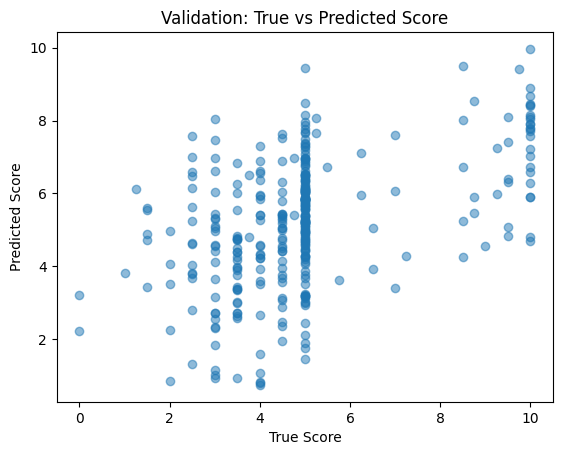

In [25]:
plt.scatter(y_val, val_pred, alpha=0.5)
plt.xlabel("True Score")
plt.ylabel("Predicted Score")
plt.title("Validation: True vs Predicted Score")
plt.show()

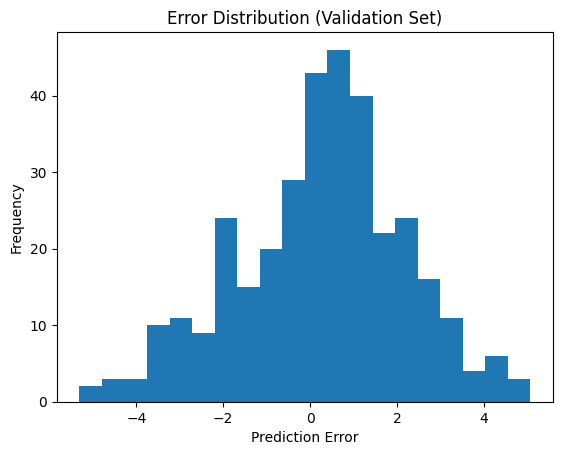

In [26]:
errors = val_pred - y_val

plt.figure()
plt.hist(errors, bins=20)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution (Validation Set)")
plt.show()

In [27]:
test_df['Predicted Score'] = test_pred
test_df.head()

,id,question,instructor_answer,student_answer,score_grader_1,score_grader_2,score_avg,Predicted Score,len_student,len_instr,len_ratio
0,E06.Q07.A13,What is a function pointer?,the address of the location in memory where th...,they are pointers that contain the addresses t...,5.0,5.0,5.0,5.687281,29,12,2.230769
1,E12.Q05.A00,What is the advantage of linked lists over arr...,linked lists are dynamic structures which allo...,a link list can grow to a infinite size as a a...,10.0,10.0,10.0,10.112705,16,16,0.941176
2,E08.Q04.A18,How can you implement a stack with a list?,keep the top of the stack pointing to the head...,elements are only inserted and removed from th...,4.0,5.0,4.5,4.530891,20,31,0.625000
3,E12.Q07.A19,What are the main operations associated with a...,push and pop,push and pop,10.0,10.0,10.0,5.859925,3,3,0.750000
4,E11.Q03.A09,How are objects initialized when they are crea...,by using constructors,constructors default when not provided by user...,10.0,10.0,10.0,5.569250,11,3,2.750000


## coba all-mpnet-base-v2

In [28]:
model = SentenceTransformer("all-mpnet-base-v2") #better for semnatic

train_student_emb = model.encode(train_df['student_answer'].tolist(), show_progress_bar=True)
train_instructor_emb = model.encode(train_df['instructor_answer'].tolist(),  show_progress_bar=True)

test_student_emb = model.encode(test_df['student_answer'])
test_instructor_emb = model.encode(test_df['instructor_answer'])

val_student_emb = model.encode(val_df['student_answer'])
val_instructor_emb = model.encode(val_df['instructor_answer'])

d:\Documents\jean\sem 5\deep learning\deep_learn_new\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\lenovo\.cache\huggingface\hub\models--sentence-transformers--all-mpnet-base-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not insta

In [29]:
train_sim = cosine_similarity(train_student_emb, train_instructor_emb).diagonal()
test_sim = cosine_similarity(test_student_emb, test_instructor_emb).diagonal()
val_sim = cosine_similarity(val_student_emb, val_instructor_emb).diagonal()

train_df['cosine sim'] = train_sim

In [30]:
train_diff = np.abs(train_student_emb - train_instructor_emb)
val_diff   = np.abs(val_student_emb - val_instructor_emb)
test_diff  = np.abs(test_student_emb - test_instructor_emb)

In [31]:
x_train = np.hstack([
    train_sim.reshape(-1, 1),
    train_df[['len_student', 'len_ratio']].values,
    train_diff
])

x_val = np.hstack([
    val_sim.reshape(-1, 1),
    val_df[['len_student', 'len_ratio']].values,
    val_diff
])

x_test = np.hstack([
    test_sim.reshape(-1, 1),
    test_df[['len_student', 'len_ratio']].values,
    test_diff
])

#merge semua fitur jadi satu tabel angka

In [32]:
y_train = train_df['score_avg'].values
y_val   = val_df['score_avg'].values

linear.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
#validation cek overfit
val_pred = linear.predict(x_val)

pearson_corr, _ = pearsonr(y_val, val_pred)
mae = mean_absolute_error(y_val, val_pred)
val_pred_round = np.rint(val_pred).astype(int)

qwk = cohen_kappa_score(
    y_val.astype(int),
    val_pred_round,
    weights="quadratic"
)

print("Pearson VAL:", pearson_corr)
print("MAE VAL:", mae)
print("QWK VAL:", qwk)

Pearson VAL: 0.5282663480209377
MAE VAL: 1.6245194958332625
QWK VAL: 0.5043996288881293


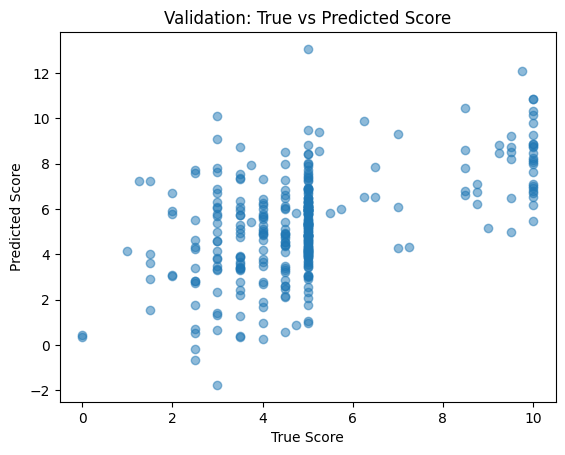

In [34]:
plt.scatter(y_val, val_pred, alpha=0.5)
plt.xlabel("True Score")
plt.ylabel("Predicted Score")
plt.title("Validation: True vs Predicted Score")
plt.show()

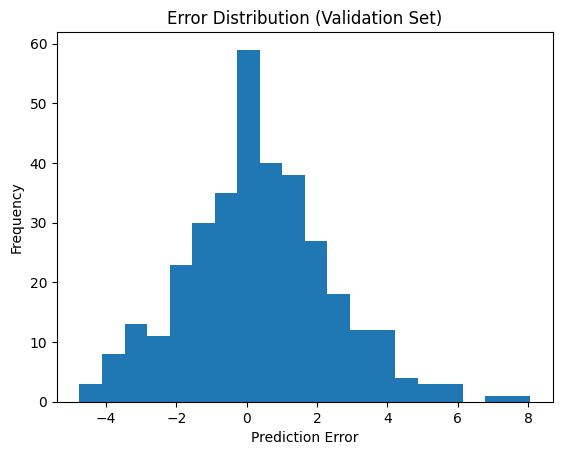

In [35]:
errors = val_pred - y_val

plt.figure()
plt.hist(errors, bins=20)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution (Validation Set)")
plt.show()

In [36]:
test_pred = linear.predict(x_test)
test_df['Predicted Score'] = test_pred
test_df.head()

,id,question,instructor_answer,student_answer,score_grader_1,score_grader_2,score_avg,Predicted Score,len_student,len_instr,len_ratio
0,E06.Q07.A13,What is a function pointer?,the address of the location in memory where th...,they are pointers that contain the addresses t...,5.0,5.0,5.0,6.041049,29,12,2.230769
1,E12.Q05.A00,What is the advantage of linked lists over arr...,linked lists are dynamic structures which allo...,a link list can grow to a infinite size as a a...,10.0,10.0,10.0,8.321343,16,16,0.941176
2,E08.Q04.A18,How can you implement a stack with a list?,keep the top of the stack pointing to the head...,elements are only inserted and removed from th...,4.0,5.0,4.5,2.531243,20,31,0.625000
3,E12.Q07.A19,What are the main operations associated with a...,push and pop,push and pop,10.0,10.0,10.0,5.957533,3,3,0.750000
4,E11.Q03.A09,How are objects initialized when they are crea...,by using constructors,constructors default when not provided by user...,10.0,10.0,10.0,8.296482,11,3,2.750000
